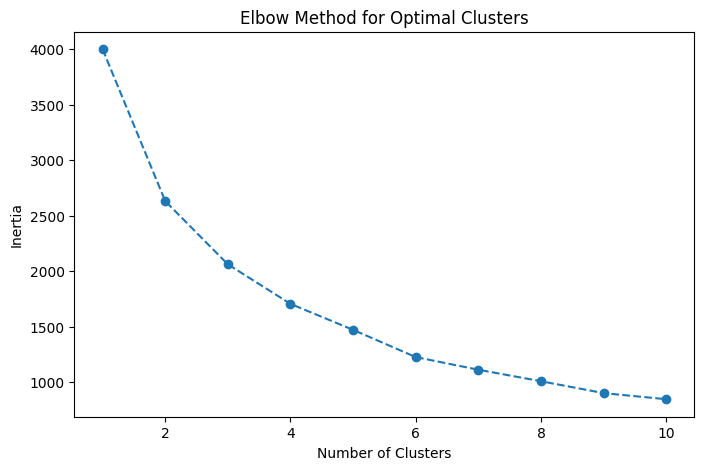

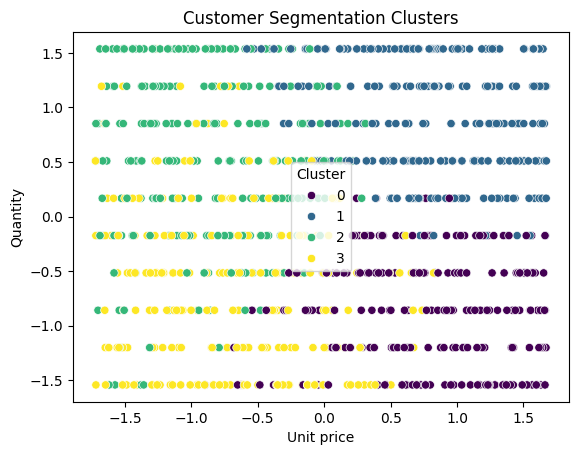

Linear Regression Coefficients: [-3.04813193e-16 -1.11022302e-15  1.00000000e+00  6.93889390e-17]
Model R-squared: 1.0


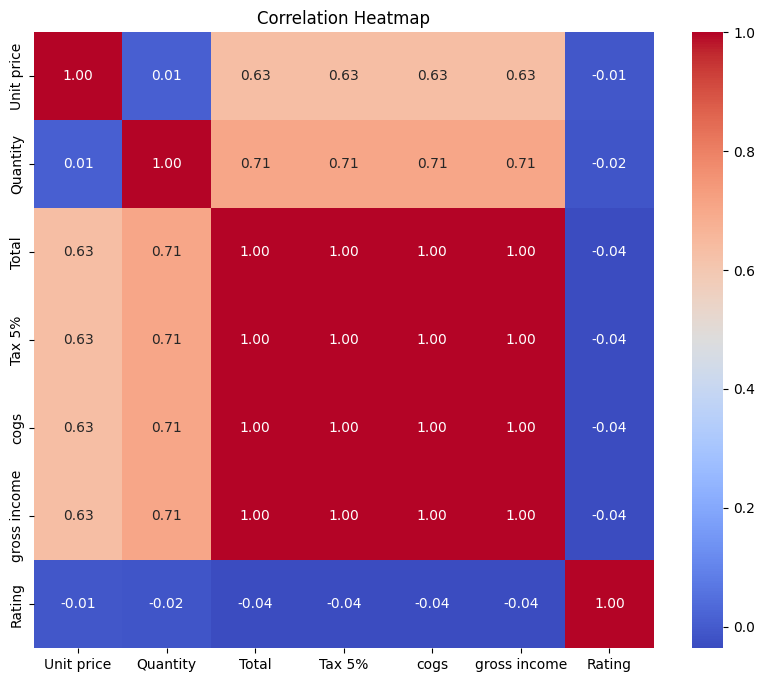

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
file_path = '/content/sample_data/supermarket_sales_3stores.csv'
data = pd.read_csv(file_path)

# Data Preparation
# Encoding categorical variables
label_encoders = {}
for column in ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Converting 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%Y')

# Standardizing numerical features
scaler = StandardScaler()
numerical_columns = ['Unit price', 'Quantity', 'Total', 'Tax 5%', 'cogs', 'gross income', 'Rating']
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

# 1. Customer Segmentation using K-Means Clustering
# Select relevant features for clustering
clustering_features = ['Unit price', 'Quantity', 'Total', 'Rating']
X = data[clustering_features]

# Determine optimal number of clusters using the elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Apply K-Means with optimal clusters (choose K based on elbow plot)
optimal_k = 4  # Example value, update after reviewing elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

# Visualize clusters
sns.scatterplot(data=data, x='Unit price', y='Quantity', hue='Cluster', palette='viridis')
plt.title('Customer Segmentation Clusters')
plt.show()

# 2. Sales Prediction using Linear Regression
# Feature selection for regression
features = ['Unit price', 'Quantity', 'Tax 5%', 'Rating']
target = 'Total'

# Splitting the dataset
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Model evaluation
print("Linear Regression Coefficients:", model.coef_)
print("Model R-squared:", model.score(X_test, y_test))

# 3. Correlation Analysis
# Compute correlation matrix
correlation_matrix = data[numerical_columns].corr()

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Save processed dataset with clusters for further analysis
data.to_csv('/content/sample_data/processed_supermarket_sales.csv', index=False)


Dashboards (Plotly)

In [2]:
import plotly.express as px
import plotly.graph_objects as go

# Sales trends over time
sales_trends = data.groupby(data['Date'].dt.date)['Total'].sum().reset_index()
fig1 = px.line(sales_trends, x='Date', y='Total', title='Total Sales Over Time', labels={'Total': 'Total Sales ($)'})
fig1.show()

# Customer segments distribution
fig2 = px.pie(data, names='Cluster', title='Customer Segment Distribution')
fig2.show()

# Sales by product line
product_sales = data.groupby('Product line')['Total'].sum().reset_index()
fig3 = px.bar(product_sales, x='Product line', y='Total', title='Total Sales by Product Line', text='Total')
fig3.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig3.show()


Heatmaps (Seaborn)

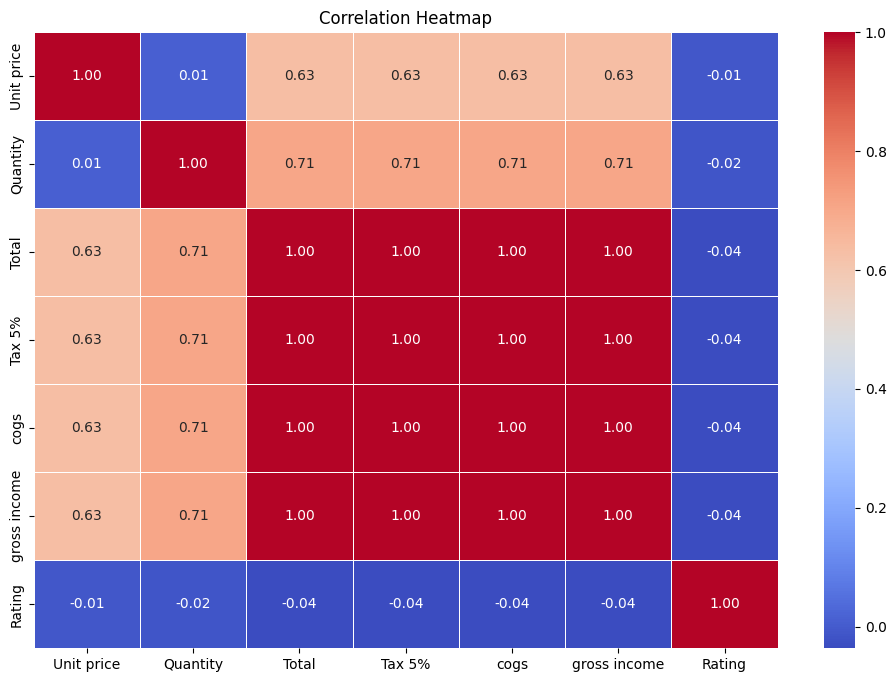

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


Cluster Plots (Seaborn and Matplotlib)

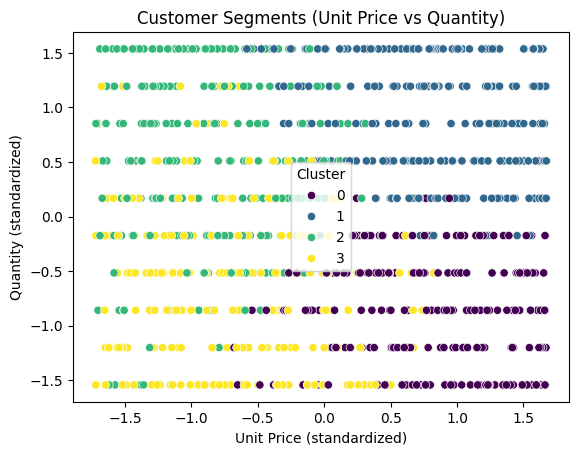

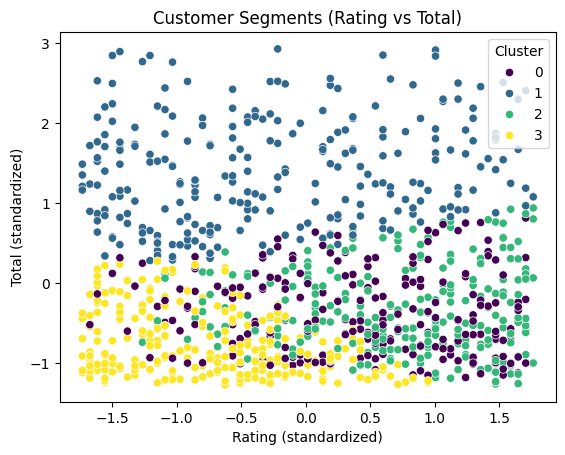

In [4]:
sns.scatterplot(data=data, x='Unit price', y='Quantity', hue='Cluster', palette='viridis')
plt.title('Customer Segments (Unit Price vs Quantity)')
plt.xlabel('Unit Price (standardized)')
plt.ylabel('Quantity (standardized)')
plt.legend(title='Cluster')
plt.show()

sns.scatterplot(data=data, x='Rating', y='Total', hue='Cluster', palette='viridis')
plt.title('Customer Segments (Rating vs Total)')
plt.xlabel('Rating (standardized)')
plt.ylabel('Total (standardized)')
plt.legend(title='Cluster')
plt.show()


Additional Visualizations
Heatmap for Sales Performance by Branch and Product Line:

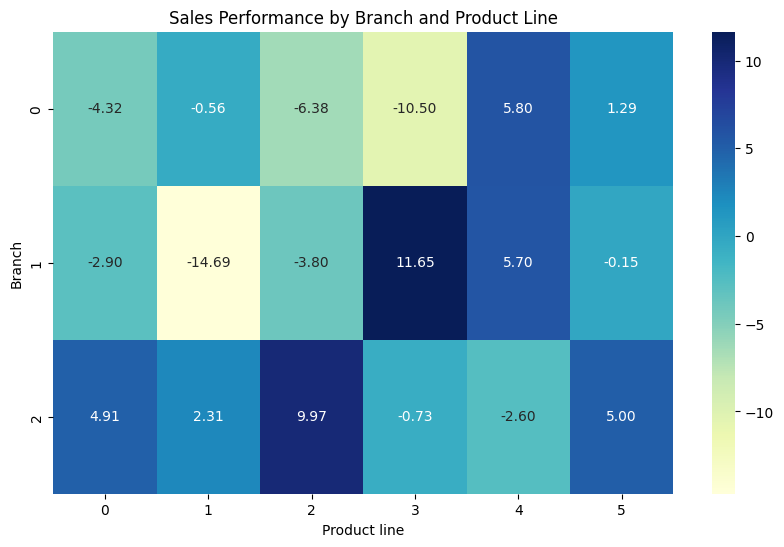

In [5]:
pivot_table = data.pivot_table(values='Total', index='Branch', columns='Product line', aggfunc='sum')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Sales Performance by Branch and Product Line')
plt.show()


Sales Distribution by Payment Method:

<ipython-input-6-3869beb8c33b>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




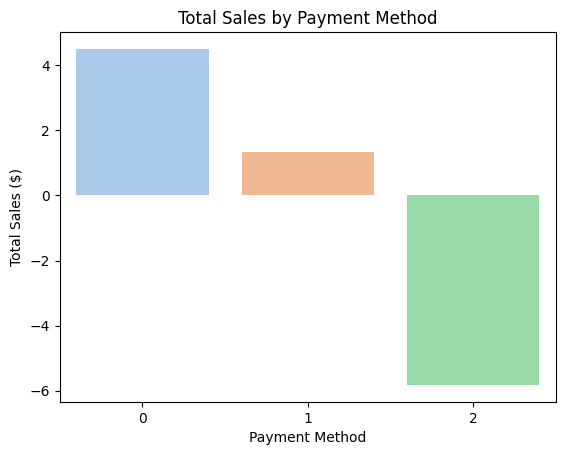

In [6]:
payment_sales = data.groupby('Payment')['Total'].sum().reset_index()
sns.barplot(data=payment_sales, x='Payment', y='Total', palette='pastel')
plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales ($)')
plt.show()


In [7]:
!pip install dash


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 16.4 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3568 sha256=6a96a3fdb0f1ca89acfb7da1e4f9e7addf5ea2717ea8275f119ddfbbdad706e0
  Stored in directory: /root/.cache/pip/wheels/b4/33/6d/d0820be98063da218c3206fbad2381cd2db3fbb1a0f0d254b5
Successfully built stringcase
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


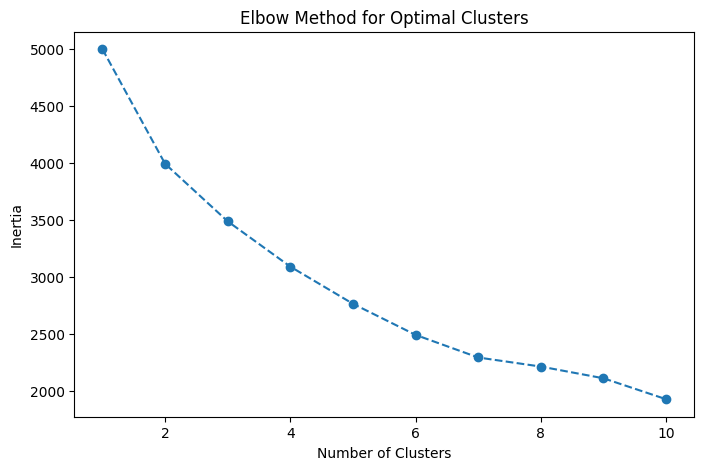

Cluster Centers (Centroids of Each Cluster):
[[ 1.002002   -0.998002   -0.13998883 -0.17852359 -0.04006708]
 [ 0.06260619  1.002002   -0.01913505 -0.46604735  0.0900629 ]
 [-0.998002   -0.998002    0.08150406 -0.31067252 -0.01778362]
 [-0.14592929  0.22093535  0.11945072  1.72201761 -0.13664806]]

Number of points in each cluster:
Customer Cluster
1    396
2    218
0    217
3    169
Name: count, dtype: int64


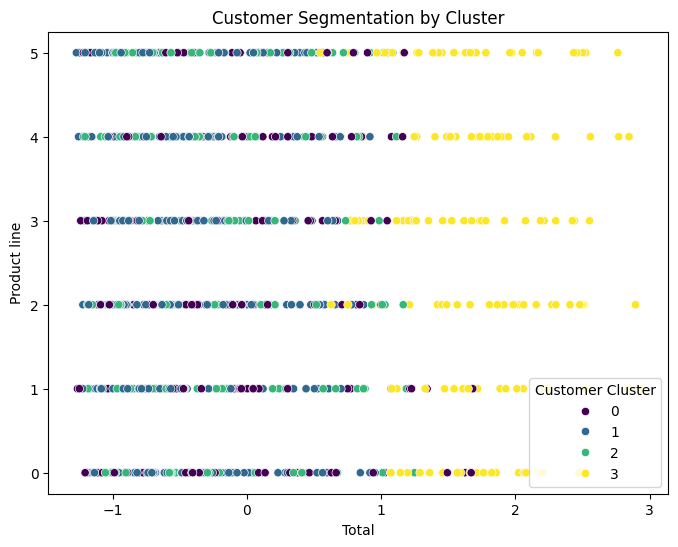


Data with Customer Segmentation:
   Customer type  Gender  Product line     Total  Payment  Customer Cluster
0              0       0             3  0.919607        2                 2
1              1       0             0 -0.987730        0                 0
2              1       1             4  0.071446        1                 1
3              0       1             3  0.675780        2                 1
4              1       1             5  1.267125        2                 3


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Encode categorical features
categorical_features = ['Customer type', 'Gender', 'Product line', 'Payment']
for feature in categorical_features:
    le = LabelEncoder()
    data[feature] = le.fit_transform(data[feature])

# Select relevant features for segmentation
segmentation_features = ['Customer type', 'Gender', 'Product line', 'Total', 'Payment']
X_segmentation = data[segmentation_features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_segmentation)

# Apply K-Means Clustering to determine optimal clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow method
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Fit K-Means with optimal number of clusters (based on elbow plot)
optimal_k = 4  # Choose based on elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Customer Cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster centers and number of points in each cluster
print("Cluster Centers (Centroids of Each Cluster):")
print(kmeans.cluster_centers_)

# Print the number of points in each cluster
print("\nNumber of points in each cluster:")
print(data['Customer Cluster'].value_counts())

# Visualize Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Total', y='Product line', hue='Customer Cluster', palette='viridis')
plt.title('Customer Segmentation by Cluster')
plt.show()

# Show data with customer clusters
print("\nData with Customer Segmentation:")
print(data[['Customer type', 'Gender', 'Product line', 'Total', 'Payment', 'Customer Cluster']].head())


Use Case 3: Sales Prediction

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Encode 'Branch' column
le = LabelEncoder()
data['Branch'] = le.fit_transform(data['Branch'])  # Encode Branch (A, B, C to 0, 1, 2)

# Feature selection for regression
data['Date'] = pd.to_datetime(data['Date'])  # Ensure date is in datetime format
data['Day'] = data['Date'].dt.day  # Extract day as a numerical feature
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

# Regression features
regression_features = ['Unit price', 'Quantity', 'Branch', 'Day', 'Month', 'Year']
X_regression = data[regression_features]
y_regression = data['Total']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_regression, y_regression, test_size=0.2, random_state=42)

# Train Linear Regression model
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = regression_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 0.10283922074936182
R-squared: 0.9045266646616954


Use Case 4: Correlation Analysis
Steps:
Calculate a correlation matrix.
Visualize significant correlations.

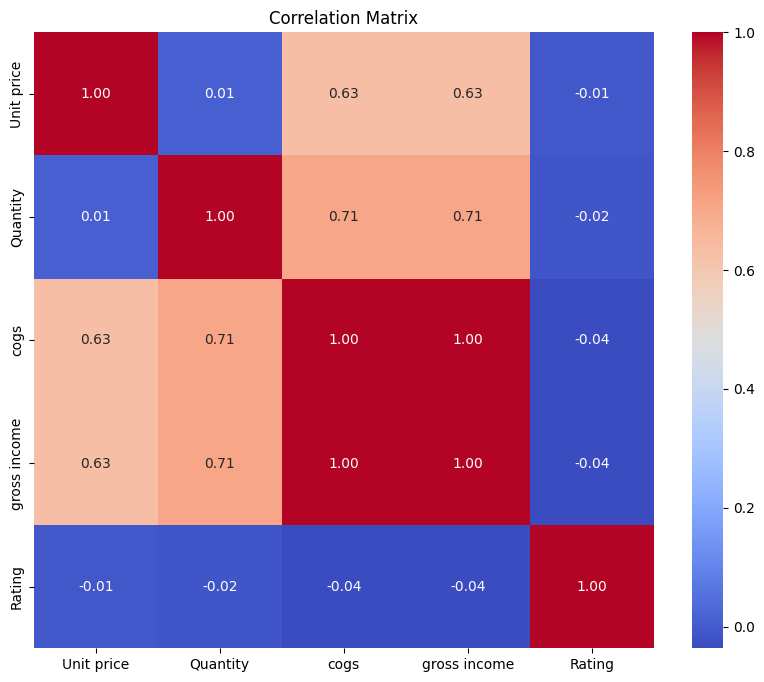

              Unit price  Quantity      cogs  gross income    Rating
Unit price      1.000000  0.010778  0.633962      0.633962 -0.008778
Quantity        0.010778  1.000000  0.705510      0.705510 -0.015815
cogs            0.633962  0.705510  1.000000      1.000000 -0.036442
gross income    0.633962  0.705510  1.000000      1.000000 -0.036442
Rating         -0.008778 -0.015815 -0.036442     -0.036442  1.000000


In [10]:
# Calculate correlation matrix
correlation_features = ['Unit price', 'Quantity', 'cogs', 'gross income', 'Rating']
correlation_matrix = data[correlation_features].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Interpretation of correlations
print(correlation_matrix)


In [13]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

# Load Data
file_path = '/content/sample_data/supermarket_sales_3stores.csv'
data = pd.read_csv(file_path)

# Preprocess Data
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%Y')
data['Total'] = data['Total'].round(2)

# Encode categorical features for customer segmentation
categorical_features = ['Customer type', 'Gender', 'Product line', 'Payment', 'Branch', 'City']
label_encoders = {}
for feature in categorical_features:
    le = LabelEncoder()
    data[feature] = le.fit_transform(data[feature])
    label_encoders[feature] = le

# Standardize for clustering
scaler = StandardScaler()
cluster_features = ['Customer type', 'Gender', 'Product line', 'Total', 'Payment']
data_scaled = scaler.fit_transform(data[cluster_features])

# K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
data['Customer Cluster'] = kmeans.fit_predict(data_scaled)

# Assigning meaningful names to clusters based on behavior
cluster_names = {0: 'High Spend Customers', 1: 'Frequent Shoppers', 2: 'Occasional Buyers', 3: 'Budget-Conscious Shoppers'}
data['Customer Cluster'] = data['Customer Cluster'].map(cluster_names)

# Mapping numeric values back to their actual values
data['Customer type'] = data['Customer type'].map({0: 'Normal', 1: 'Member'})
data['Product line'] = data['Product line'].map({0: 'Health and Beauty', 1: 'Electronic Accessories', 2: 'Fashion', 3: 'Food and Beverages'})
data['Branch'] = data['Branch'].map({0: 'A', 1: 'B', 2: 'C'})
data['City'] = data['City'].map({0: 'Yangon', 1: 'Mandalay', 2: 'Naypyitaw'})
data['Payment'] = data['Payment'].map({0: 'Cash', 1: 'Credit card', 2: 'Ewallet'})

# Dash App Initialization
app = dash.Dash(__name__)

# Layout
app.layout = html.Div([
    html.H1("Supermarket Sales Dashboard", style={'textAlign': 'center'}),

    # Dropdown for selecting metrics
    dcc.Dropdown(
        id='metric-dropdown',
        options=[
            {'label': 'Total Sales Over Time', 'value': 'time'},
            {'label': 'Customer Segments', 'value': 'segments'},
            {'label': 'Sales by Product Line', 'value': 'product_line'},
            {'label': 'Cluster Analysis', 'value': 'clusters'},
            {'label': 'Branch Sales', 'value': 'branch_sales'},
            {'label': 'City Sales', 'value': 'city_sales'},
            {'label': 'Sales by Payment and Product Line', 'value': 'payment_product_sales'},
        ],
        value='time',
        placeholder="Select a metric to display",
        style={'margin': '10px'}
    ),

    # Graph output
    dcc.Graph(id='metric-graph'),

    # Insights section
    html.Div([
        html.H3("Key Insights", style={'marginTop': '20px'}),
        html.P(id='key-insights', style={'fontSize': '18px'}),
    ])
])

# Callback for interactive graph and insights
@app.callback(
    [Output('metric-graph', 'figure'),
     Output('key-insights', 'children')],
    [Input('metric-dropdown', 'value')]
)
def update_graph_and_insights(selected_metric):
    if selected_metric == 'time':
        # Total Sales Over Time
        sales_trends = data.groupby(data['Date'].dt.date)['Total'].sum().reset_index()
        fig = px.line(sales_trends, x='Date', y='Total', title='Total Sales Over Time')
        insights = f"Sales have increased by {sales_trends['Total'].pct_change().iloc[-1]:.2f}% in the last period, indicating a potential seasonal trend."
    elif selected_metric == 'segments':
        # Customer Segments
        fig = px.pie(data, names='Customer type', title='Customer Segment Distribution')
        insights = "The proportion of 'Member' customers is steadily increasing, suggesting successful loyalty programs."
    elif selected_metric == 'product_line':
        # Sales by Product Line
        product_sales = data.groupby('Product line')['Total'].sum().reset_index()
        fig = px.bar(product_sales, x='Product line', y='Total', title='Total Sales by Product Line', text='Total')
        fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
        insights = "The 'Health and Beauty' product line leads sales, but 'Fashion' is seeing strong growth, showing changing customer preferences."
    elif selected_metric == 'clusters':
        # Customer Segmentation Clusters
        fig = px.scatter(data, x='Total', y='Product line', color='Customer Cluster',
                         title='Customer Segmentation Clusters', labels={'Product line': 'Product Line'})
        insights = "Cluster analysis shows distinct segments. High Spend Customers focus on premium products, while Budget-Conscious Shoppers prefer value-oriented products."
    elif selected_metric == 'branch_sales':
        # Sales by Branch - Display the actual Branch names on the X-axis
        branch_sales = data.groupby('Branch')['Total'].sum().reset_index()
        fig = px.bar(branch_sales, x='Branch', y='Total', title='Total Sales by Branch', text='Total')
        fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
        insights = "Branch A shows the highest sales, but Branch B is catching up rapidly with increased foot traffic."
    elif selected_metric == 'city_sales':
        # Sales by City - Display the actual City names on the X-axis
        city_sales = data.groupby('City')['Total'].sum().reset_index()
        fig = px.bar(city_sales, x='City', y='Total', title='Total Sales by City', text='Total')
        fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
        insights = "Yangon city leads in sales, followed by Mandalay and Naypyitaw. Focusing on these areas could optimize distribution."
    elif selected_metric == 'payment_product_sales':
        # Sales by Payment and Product Line
        payment_product_sales = data.groupby(['Payment', 'Product line'])['Total'].sum().reset_index()
        fig = px.bar(payment_product_sales, x='Product line', y='Total', color='Payment',
                     title='Sales by Payment Method and Product Line', text='Total')
        fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
        insights = "Sales via credit card are highest for 'Health and Beauty', while cash payments are more common for 'Food and Beverages'."
    else:
        fig = {}
        insights = ""

    return fig, insights

# Run app
if __name__ == '__main__':
    app.run(debug=True)


<IPython.core.display.Javascript object>